# O1 depth-policy analysis across benchmark seeds

# Part I — Incrementing-depth policies

Analysis of 47 incrementing-depth policies on five O1 landscapes and five paired SMAC seeds. Landscape-level policy selection averages over SMAC seeds; lower regret and lower rank are better.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

BENCHMARK_SEEDS = (52, 53, 54, 55, 56)
SMAC_SEEDS = tuple(range(5))
FIXED_DEPTHS = (5, 10, 15, 20)
EXPECTED_POLICIES = 47
candidates = [Path.cwd(), Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/05_02_individual_polciies']
HERE = next((p for p in candidates if (p / 'o1_increment_policy_runner.py').exists()), None)
if HERE is None: raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())


/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/05_02_individual_polciies


## Load, validate, and audit completeness

In [2]:
rows, curves = [], {}
for family in ('policies', 'fixed'):
    for path in sorted((OUTPUT / family).rglob('trajectory.json')):
        data = json.loads(path.read_text())
        best = np.asarray(data['best_regret'], float)
        bseed, sseed = int(data['benchmark_seed']), int(data['smac_seed'])
        key = (family, bseed, data['policy'], sseed)
        if key in curves: raise ValueError(f'Duplicate trajectory: {key}')
        curves[key] = best
        spec = data.get('policy_spec')
        rows.append({
            'family': family, 'policy': data['policy'], 'benchmark_seed': bseed, 'smac_seed': sseed,
            'policy_family': None if spec is None else spec['family'],
            'start_depth': data.get('max_depth') if spec is None else int(spec['start_depth']),
            'interval': None if spec is None else int(spec['interval']),
            'stop_after': None if spec is None else spec['stop_after'],
            'final_depth': data.get('max_depth') if spec is None else int(data['planned_depth_at_999']),
            'r250': float(best[249]), 'r400': float(best[399]), 'r600': float(best[599]),
            'r800': float(best[799]), 'final_regret': float(best[-1]),
            'mean_regret': float(best.mean()),
            'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
            'n_trials': int(data['n_trials']), 'problem_seed': int(data['problem_seed']),
            'pythonhashseed': str(data['pythonhashseed']), 'path': path,
        })
results = pd.DataFrame(rows)
if results.empty: raise FileNotFoundError(f'No trajectories found below {OUTPUT}.')
bad = results.query("n_trials != 1000 or problem_seed != benchmark_seed or pythonhashseed != '12345'")
if not bad.empty: display(bad); raise ValueError('Incompatible trajectory metadata.')
dynamic = results.query("family == 'policies'").copy()
fixed = results.query("family == 'fixed'").copy()
dynamic_counts = dynamic.groupby(['benchmark_seed', 'policy']).smac_seed.nunique()
fixed_counts = fixed.groupby(['benchmark_seed', 'policy']).smac_seed.nunique() if not fixed.empty else pd.Series(dtype=int)
print(f'Loaded {len(dynamic)}/{EXPECTED_POLICIES * 25} dynamic and {len(fixed)}/{len(FIXED_DEPTHS) * 25} fixed trajectories.')
print('Complete dynamic benchmark/policy pairs:', int(dynamic_counts.eq(5).sum()), '/', EXPECTED_POLICIES * 5)
print('Complete fixed benchmark/policy pairs:', int(fixed_counts.eq(5).sum()), '/', len(FIXED_DEPTHS) * 5)
display(dynamic.groupby('policy_family').policy.nunique().rename('policies').to_frame())


Loaded 1175/1175 dynamic and 100/100 fixed trajectories.
Complete dynamic benchmark/policy pairs: 235 / 235
Complete fixed benchmark/policy pairs: 20 / 20


,policies
policy_family,
a,7
b,10
c,8
d,11
e,11


## Policy definitions

The curves below show the planned maximum depth as a function of completed trials. Family c stops increasing after trial 400.

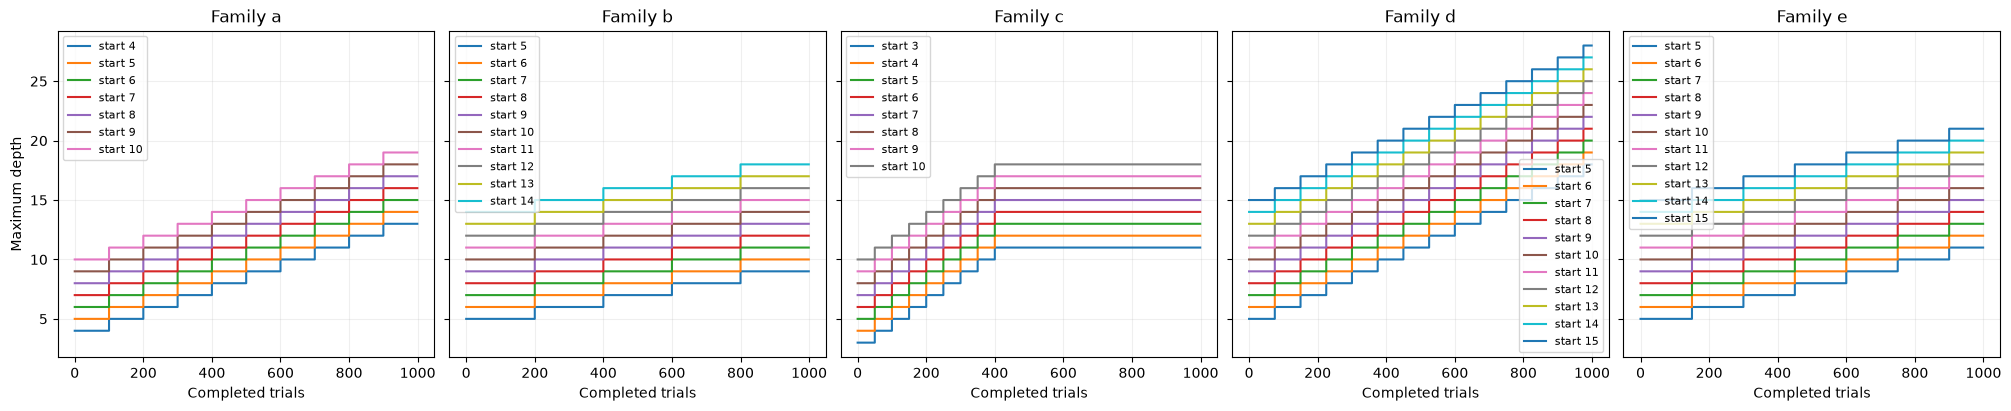

In [3]:
definitions = dynamic[['policy','policy_family','start_depth','interval','stop_after','final_depth']].drop_duplicates().sort_values(['policy_family','start_depth'])
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True, constrained_layout=True)
trials = np.arange(1000)
for ax, (family, group) in zip(axes, definitions.groupby('policy_family')):
    for row in group.itertuples():
        effective = trials if pd.isna(row.stop_after) else np.minimum(trials, int(row.stop_after))
        depth = row.start_depth + effective // row.interval
        ax.step(trials, depth, where='post', label=f'start {row.start_depth}')
    ax.set_title(f'Family {family}'); ax.set_xlabel('Completed trials'); ax.grid(alpha=.2); ax.legend(fontsize=8)
axes[0].set_ylabel('Maximum depth')
plt.show()


## Rankings within each benchmark landscape

In [4]:
complete = dynamic.groupby(['benchmark_seed','policy']).filter(lambda x: x.smac_seed.nunique() == 5)
by_benchmark = (complete.groupby(['benchmark_seed','policy','policy_family','start_depth','interval','stop_after','final_depth'], dropna=False, as_index=False)
    .agg(mean_r250=('r250','mean'), mean_r400=('r400','mean'), mean_r600=('r600','mean'), mean_r800=('r800','mean'),
         mean_final=('final_regret','mean'), std_final=('final_regret','std'), median_final=('final_regret','median'),
         mean_regret=('mean_regret','mean'), mean_log_auc=('log_auc','mean')))
by_benchmark['final_rank'] = by_benchmark.groupby('benchmark_seed').mean_final.rank(method='average')
by_benchmark['auc_rank'] = by_benchmark.groupby('benchmark_seed').mean_log_auc.rank(method='average')
for bseed in BENCHMARK_SEEDS:
    table = by_benchmark.query('benchmark_seed == @bseed').sort_values(['mean_final','mean_regret']).head(10).reset_index(drop=True)
    table.index = np.arange(1, len(table) + 1); table.index.name = 'rank'
    print(f'\nBenchmark seed {bseed}: top 10'); display(table[['policy','policy_family','start_depth','interval','stop_after','final_depth','mean_final','std_final','mean_log_auc']])



Benchmark seed 52: top 10


,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,d_increase_75_start_5,d,5,75.0,NaN,18,9748.861416,1908.886704,4.609198
2,c_increase_50_start_4_hold_after_400,c,4,50.0,400.0,12,10043.390750,2976.134609,4.552969
3,c_increase_50_start_6_hold_after_400,c,6,50.0,400.0,14,10303.818052,5003.783607,4.603782
4,a_increase_100_start_9,a,9,100.0,NaN,18,11513.541406,6248.517066,4.587962
5,b_increase_200_start_10,b,10,200.0,NaN,14,12074.774153,2819.620913,4.650281
6,e_increase_150_start_9,e,9,150.0,NaN,15,12223.228150,4145.289085,4.571182
7,d_increase_75_start_9,d,9,75.0,NaN,22,12285.892739,5031.461613,4.635471
8,a_increase_100_start_5,a,5,100.0,NaN,14,12366.488220,8359.348799,4.617924
9,b_increase_200_start_12,b,12,200.0,NaN,16,12523.336456,3983.900032,4.619404



Benchmark seed 53: top 10


,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,a_increase_100_start_8,a,8,100.0,NaN,17,8484.564387,3585.411661,4.569747
2,d_increase_75_start_9,d,9,75.0,NaN,22,8691.331884,5060.712579,4.525710
3,c_increase_50_start_4_hold_after_400,c,4,50.0,400.0,12,9233.356774,4396.594115,4.457238
4,e_increase_150_start_9,e,9,150.0,NaN,15,9416.479059,1145.494485,4.528403
5,e_increase_150_start_10,e,10,150.0,NaN,16,10356.616483,3530.976122,4.569879
6,c_increase_50_start_6_hold_after_400,c,6,50.0,400.0,14,10395.696663,2789.119396,4.491533
7,b_increase_200_start_12,b,12,200.0,NaN,16,10805.113072,2840.973580,4.527537
8,b_increase_200_start_14,b,14,200.0,NaN,18,10955.610679,5907.266101,4.544403
9,e_increase_150_start_8,e,8,150.0,NaN,14,11030.797888,2598.011735,4.490999



Benchmark seed 54: top 10


,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,c_increase_50_start_8_hold_after_400,c,8,50.0,400.0,16,8741.009125,1715.862244,4.528485
2,a_increase_100_start_10,a,10,100.0,NaN,19,10711.716809,3187.614796,4.507883
3,b_increase_200_start_14,b,14,200.0,NaN,18,10818.827338,4981.313911,4.527096
4,d_increase_75_start_10,d,10,75.0,NaN,23,10884.458195,5513.029170,4.518358
5,a_increase_100_start_8,a,8,100.0,NaN,17,11117.376898,5004.900430,4.517526
6,e_increase_150_start_13,e,13,150.0,NaN,19,11125.131209,4064.439632,4.531276
7,d_increase_75_start_7,d,7,75.0,NaN,20,11195.915918,2613.409822,4.539535
8,d_increase_75_start_6,d,6,75.0,NaN,19,11200.381907,2310.911640,4.561131
9,c_increase_50_start_4_hold_after_400,c,4,50.0,400.0,12,11524.622538,1780.296791,4.512320



Benchmark seed 55: top 10


,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,d_increase_75_start_8,d,8,75.0,NaN,21,5491.475151,1467.157134,4.350984
2,e_increase_150_start_15,e,15,150.0,NaN,21,5619.445070,1282.232695,4.375855
3,c_increase_50_start_10_hold_after_400,c,10,50.0,400.0,18,5631.306004,1964.145457,4.355983
4,d_increase_75_start_13,d,13,75.0,NaN,26,5657.937194,1442.023443,4.383528
5,d_increase_75_start_14,d,14,75.0,NaN,27,6121.558831,2143.192112,4.387739
6,d_increase_75_start_15,d,15,75.0,NaN,28,6121.558831,2143.192112,4.387739
7,d_increase_75_start_12,d,12,75.0,NaN,25,6204.072183,2445.933222,4.390940
8,d_increase_75_start_11,d,11,75.0,NaN,24,6246.033875,3284.030074,4.383446
9,c_increase_50_start_4_hold_after_400,c,4,50.0,400.0,12,6584.403617,1444.649094,4.331671



Benchmark seed 56: top 10


,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,c_increase_50_start_10_hold_after_400,c,10,50.0,400.0,18,4734.458000,1469.760663,4.280524
2,b_increase_200_start_11,b,11,200.0,NaN,15,5170.455898,2088.448563,4.255147
3,d_increase_75_start_12,d,12,75.0,NaN,25,5493.507754,2706.001543,4.285371
4,e_increase_150_start_14,e,14,150.0,NaN,20,5886.682606,2059.549668,4.285071
5,e_increase_150_start_11,e,11,150.0,NaN,17,5924.793892,2744.072076,4.269385
6,b_increase_200_start_14,b,14,200.0,NaN,18,6231.384991,3203.881481,4.324834
7,d_increase_75_start_13,d,13,75.0,NaN,26,6380.171573,2801.485296,4.300701
8,d_increase_75_start_14,d,14,75.0,NaN,27,6380.171573,2801.485296,4.300701
9,d_increase_75_start_15,d,15,75.0,NaN,28,6380.171573,2801.485296,4.300701


## What works across benchmark landscapes?

,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_rank,median_rank,worst_rank,rank_std,geomean_ratio,mean_auc_rank
cross-landscape rank,,,,,,,,,,,,
1,c_increase_50_start_4_hold_after_400,c,4,50.0,400.0,12,7.8,9.0,16.0,5.630275,1.220438,7.0
2,e_increase_150_start_14,e,14,150.0,NaN,20,12.8,11.0,28.0,8.983318,1.361587,21.2
3,e_increase_150_start_15,e,15,150.0,NaN,21,13.6,14.0,21.0,7.700649,1.361901,19.8
4,d_increase_75_start_11,d,11,75.0,NaN,24,15.0,14.0,23.0,5.522681,1.362877,22.8
5,a_increase_100_start_9,a,9,100.0,NaN,18,15.0,18.0,21.0,6.819091,1.454367,19.0
6,d_increase_75_start_9,d,9,75.0,NaN,22,15.2,13.0,28.0,11.476062,1.371331,16.8
7,b_increase_200_start_14,b,14,200.0,NaN,18,15.6,8.0,31.0,13.722245,1.424204,24.0
8,b_increase_200_start_12,b,12,200.0,NaN,16,16.4,14.0,32.0,10.064790,1.429066,16.0
9,d_increase_75_start_12,d,12,75.0,NaN,25,16.8,17.0,34.0,12.457929,1.373616,23.0


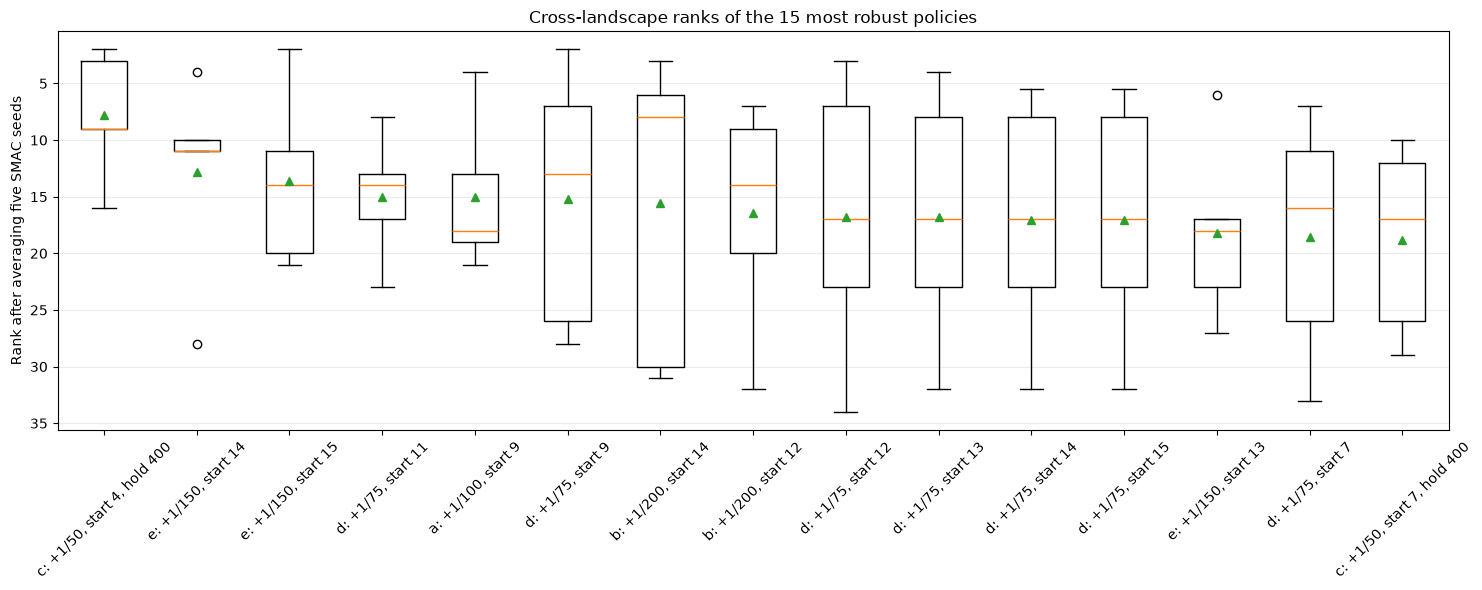

In [5]:
if any(by_benchmark.query('benchmark_seed == @b').policy.nunique() != EXPECTED_POLICIES for b in BENCHMARK_SEEDS):
    raise ValueError('Cross-landscape analysis requires all policies on every benchmark seed.')
by_benchmark['best_mean'] = by_benchmark.groupby('benchmark_seed').mean_final.transform('min')
by_benchmark['ratio_to_best'] = by_benchmark.mean_final / by_benchmark.best_mean
cross = (by_benchmark.groupby(['policy','policy_family','start_depth','interval','stop_after','final_depth'], dropna=False, as_index=False)
    .agg(mean_rank=('final_rank','mean'), median_rank=('final_rank','median'), worst_rank=('final_rank','max'),
         rank_std=('final_rank','std'), geomean_ratio=('ratio_to_best', lambda x: float(np.exp(np.log(x).mean()))),
         mean_auc_rank=('auc_rank','mean')))
cross = cross.sort_values(['mean_rank','geomean_ratio','worst_rank']).reset_index(drop=True)
cross.index = np.arange(1, len(cross) + 1); cross.index.name = 'cross-landscape rank'
top = cross.head(15); display(top)
rank_lists = [by_benchmark.query('policy == @p').sort_values('benchmark_seed').final_rank for p in top.policy]
labels = [p.replace('_increase_', ': +1/').replace('_start_', ', start ').replace('_hold_after_', ', hold ') for p in top.policy]
fig, ax = plt.subplots(figsize=(15, 6)); ax.boxplot(rank_lists, tick_labels=labels, showmeans=True)
ax.set_ylabel('Rank after averaging five SMAC seeds'); ax.invert_yaxis(); ax.set_title('Cross-landscape ranks of the 15 most robust policies')
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()


### Single-run paired-rank variability

Each box contains 25 ranks, one for every matched benchmark-seed/SMAC-seed pair. This describes optimizer-seed variability; the five-point landscape-aggregated plot above remains the primary transfer view.

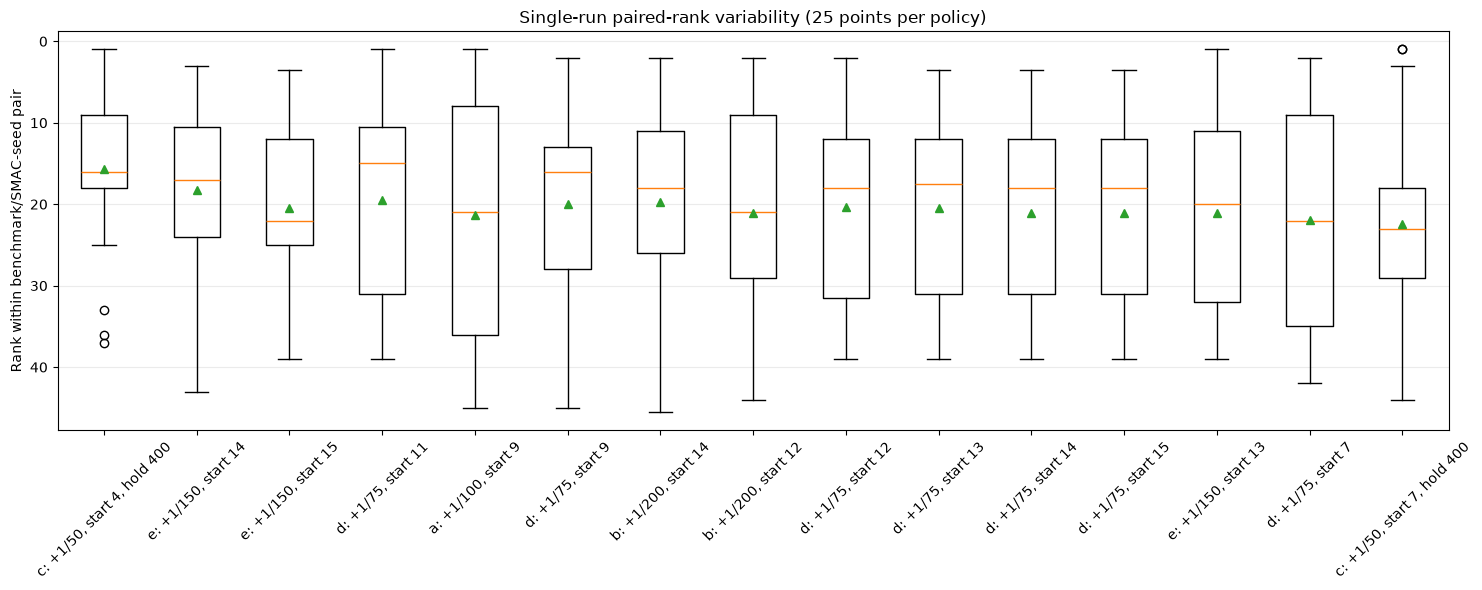

In [6]:
paired = complete.copy()
pair_sizes = paired.groupby(['benchmark_seed','smac_seed']).policy.nunique()
if not pair_sizes.eq(EXPECTED_POLICIES).all(): raise ValueError('Every pair must contain all policies.')
paired['paired_rank'] = paired.groupby(['benchmark_seed','smac_seed']).final_regret.rank(method='average')
paired_lists = [paired.query('policy == @p').sort_values(['benchmark_seed','smac_seed']).paired_rank for p in top.policy]
if not all(len(values) == 25 for values in paired_lists): raise ValueError('Expected 25 ranks per policy.')
fig, ax = plt.subplots(figsize=(15, 6)); ax.boxplot(paired_lists, tick_labels=labels, showmeans=True)
ax.set_ylabel('Rank within benchmark/SMAC-seed pair'); ax.invert_yaxis(); ax.set_title('Single-run paired-rank variability (25 points per policy)')
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()


## Which policy families and starting depths transfer?

,policies,mean_cross_rank,median_cross_rank,best_cross_rank,mean_ratio
depth schedule,,,,,
+1 every 75 trials,11,20.145455,17.1,15.0,1.482825
+1 every 50 trials; hold after trial 400,8,22.675000,23.1,7.8,1.518728
+1 every 150 trials,11,24.163636,22.6,12.8,1.638910
+1 every 100 trials,7,25.114286,22.8,15.0,1.646807
+1 every 200 trials,10,28.340000,27.6,15.6,1.749820


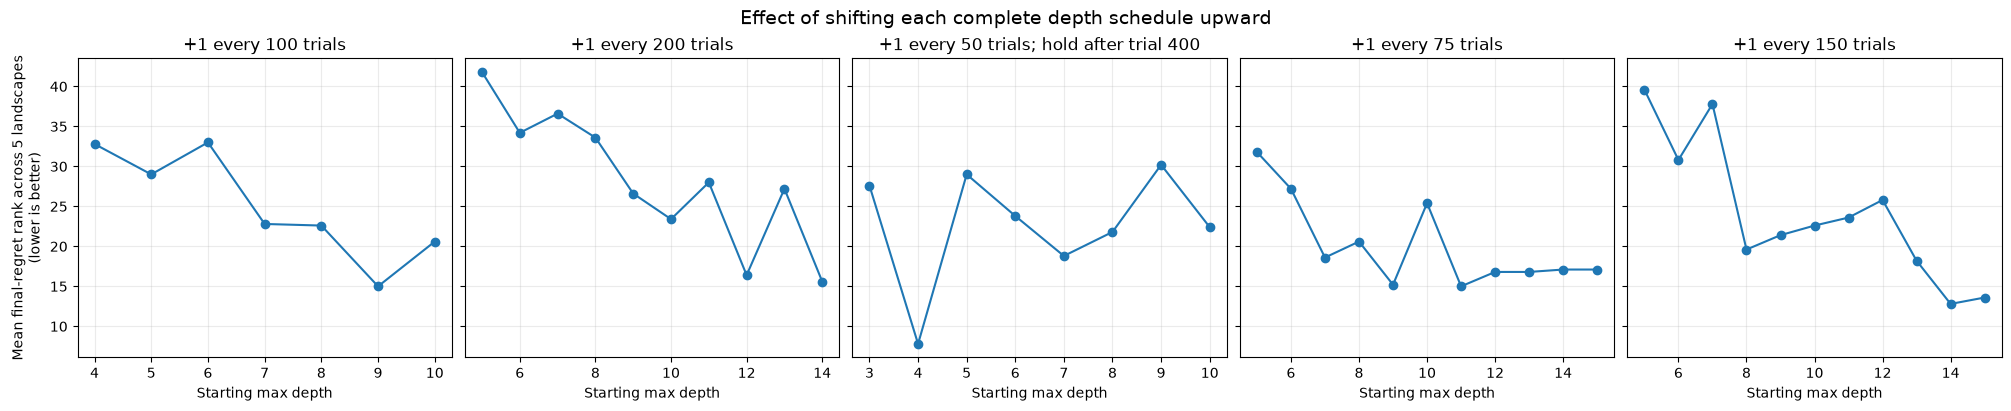

,policy,policy_family,start_depth,interval,stop_after,final_depth,mean_auc_rank,mean_rank
cross-landscape rank,,,,,,,,
1,c_increase_50_start_4_hold_after_400,c,4,50.0,400.0,12,7.0,7.8
15,c_increase_50_start_7_hold_after_400,c,7,50.0,400.0,15,10.8,18.8
17,d_increase_75_start_8,d,8,75.0,NaN,21,14.2,20.6
33,c_increase_50_start_3_hold_after_400,c,3,50.0,400.0,11,15.8,27.6
8,b_increase_200_start_12,b,12,200.0,NaN,16,16.0,16.4
16,e_increase_150_start_8,e,8,150.0,NaN,14,16.2,19.6
6,d_increase_75_start_9,d,9,75.0,NaN,22,16.8,15.2
30,b_increase_200_start_9,b,9,200.0,NaN,13,18.8,26.6
5,a_increase_100_start_9,a,9,100.0,NaN,18,19.0,15.0


In [7]:
FAMILY_LABELS = {
    'a': '+1 every 100 trials',
    'b': '+1 every 200 trials',
    'c': '+1 every 50 trials; hold after trial 400',
    'd': '+1 every 75 trials',
    'e': '+1 every 150 trials',
}
family_summary = cross.groupby('policy_family').agg(policies=('policy','size'), mean_cross_rank=('mean_rank','mean'), median_cross_rank=('mean_rank','median'), best_cross_rank=('mean_rank','min'), mean_ratio=('geomean_ratio','mean')).sort_values('mean_cross_rank')
family_summary.index = family_summary.index.map(FAMILY_LABELS)
family_summary.index.name = 'depth schedule'
display(family_summary)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True, constrained_layout=True)
for ax, (family, group) in zip(axes, cross.groupby('policy_family')):
    group = group.sort_values('start_depth'); ax.plot(group.start_depth, group.mean_rank, marker='o')
    ax.set_title(FAMILY_LABELS[family]); ax.set_xlabel('Starting max depth'); ax.grid(alpha=.25)
axes[0].set_ylabel('Mean final-regret rank across 5 landscapes\n(lower is better)')
fig.suptitle('Effect of shifting each complete depth schedule upward', fontsize=14)
plt.show()
display(cross.sort_values('mean_auc_rank').head(15)[['policy','policy_family','start_depth','interval','stop_after','final_depth','mean_auc_rank','mean_rank']])


## Top policies versus fixed depths

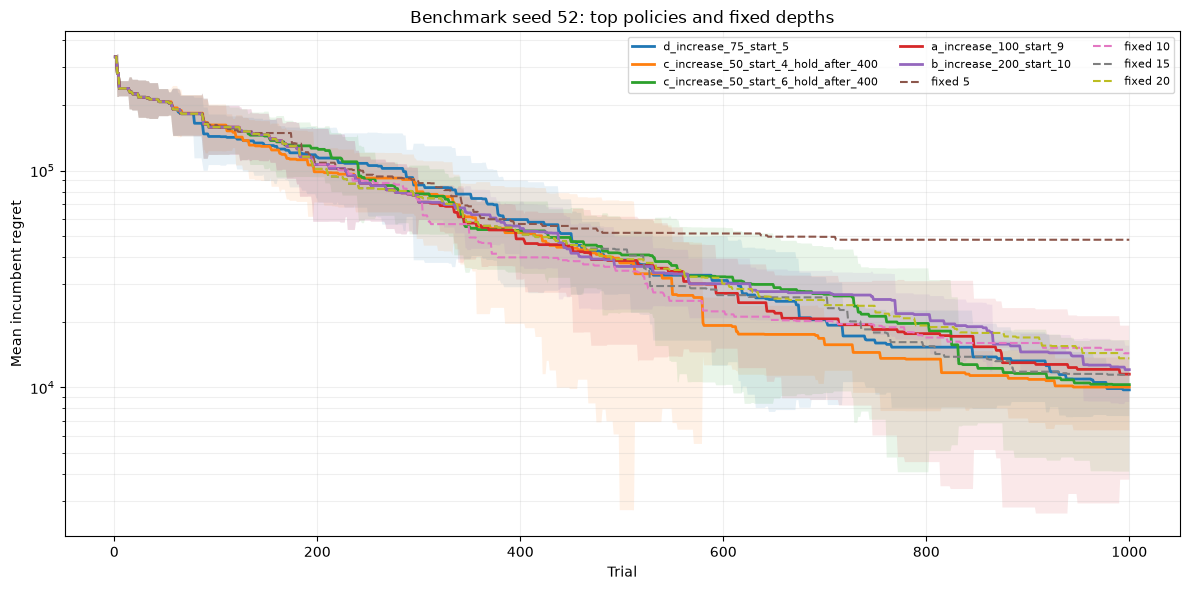

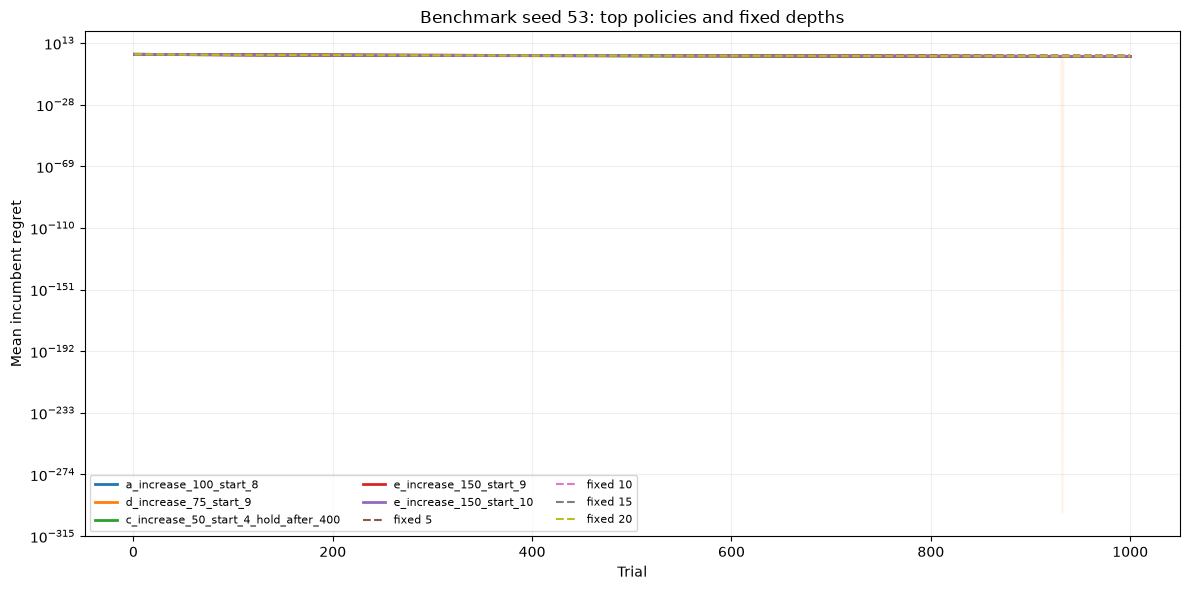

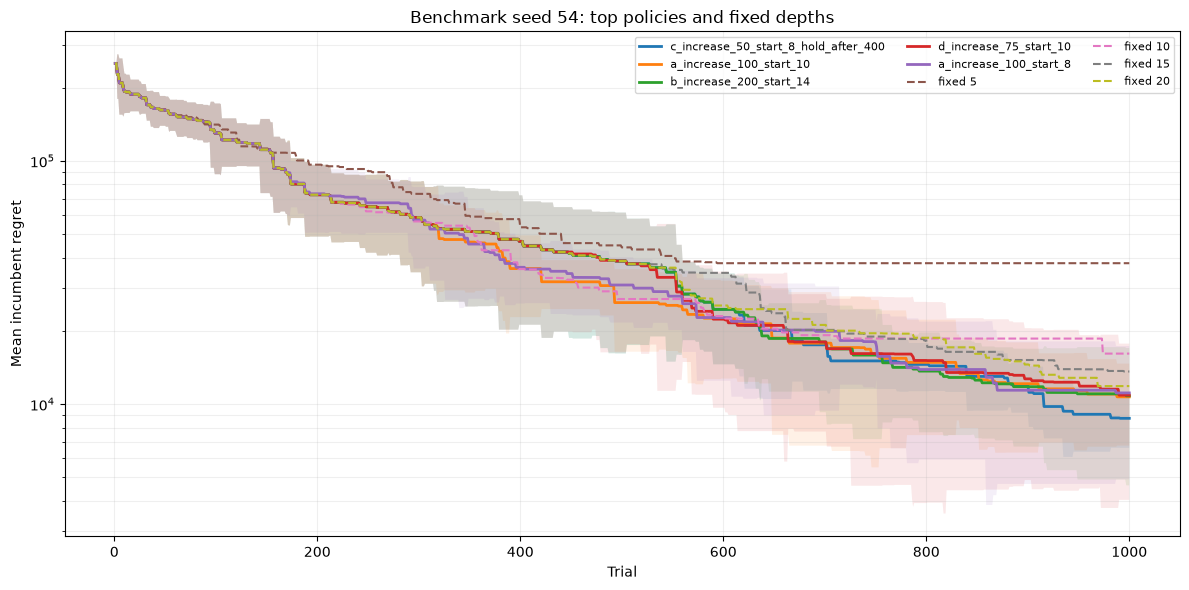

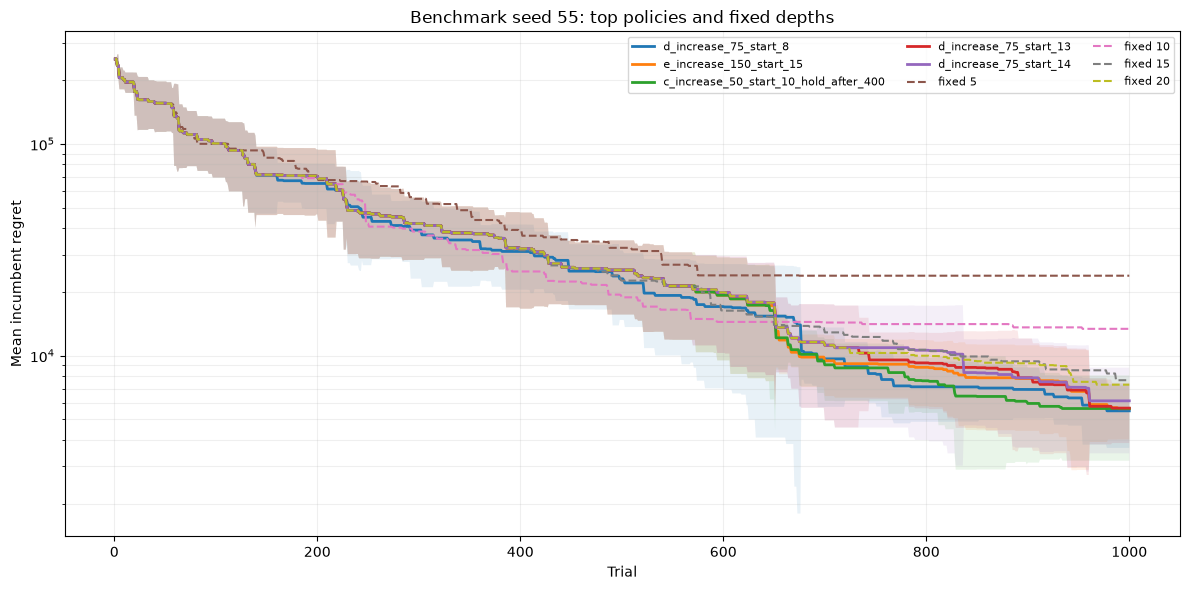

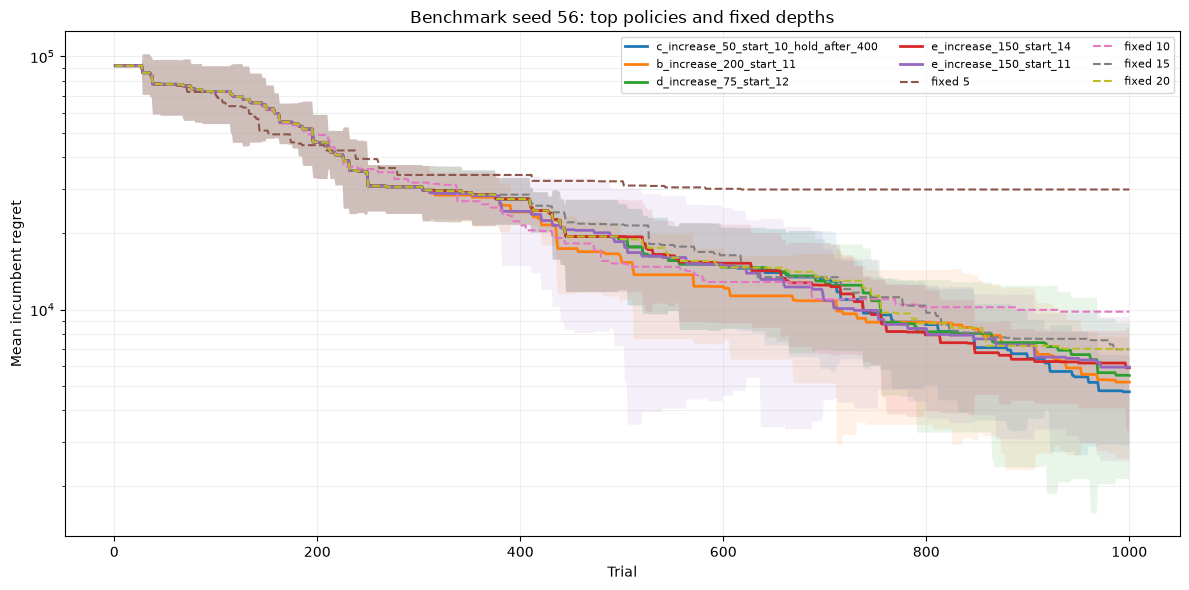

In [8]:
fixed_complete = fixed.groupby(['benchmark_seed','policy']).filter(lambda x: x.smac_seed.nunique() == 5)
fixed_by_benchmark = fixed_complete.groupby(['benchmark_seed','policy'], as_index=False).agg(mean_final=('final_regret','mean'), mean_log_auc=('log_auc','mean'))
for bseed in BENCHMARK_SEEDS:
    selected = by_benchmark.query('benchmark_seed == @bseed').nsmallest(5, 'mean_final').policy.tolist()
    fig, ax = plt.subplots(figsize=(12, 6))
    for policy in selected:
        matrix = np.vstack([curves[('policies', bseed, policy, seed)] for seed in SMAC_SEEDS])
        mean = matrix.mean(0); margin = t.ppf(.975, 4) * matrix.std(0, ddof=1) / np.sqrt(5)
        ax.plot(np.arange(1,1001), np.maximum(mean,1e-300), lw=2, label=policy)
        ax.fill_between(np.arange(1,1001), np.maximum(mean-margin,1e-300), np.maximum(mean+margin,1e-300), alpha=.1)
    for depth in FIXED_DEPTHS:
        keys = [('fixed', bseed, f'fixed_depth_{depth}', seed) for seed in SMAC_SEEDS]
        if all(key in curves for key in keys):
            matrix = np.vstack([curves[key] for key in keys]); ax.plot(np.arange(1,1001), np.maximum(matrix.mean(0),1e-300), ls='--', label=f'fixed {depth}')
    ax.set_yscale('log'); ax.set_xlabel('Trial'); ax.set_ylabel('Mean incumbent regret'); ax.set_title(f'Benchmark seed {bseed}: top policies and fixed depths')
    ax.legend(fontsize=8, ncol=3); ax.grid(alpha=.2, which='both'); plt.tight_layout(); plt.show()


## Agreement of policy rankings between landscapes

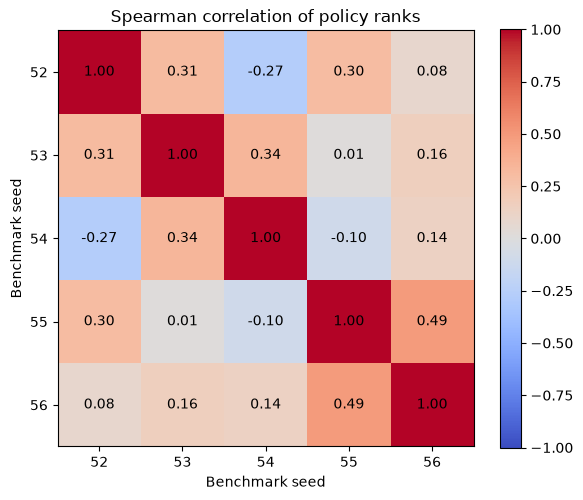

benchmark_seed,52,53,54,55,56
benchmark_seed,,,,,
52,1.000000,0.312312,-0.272054,0.298748,0.081463
53,0.312312,1.000000,0.338463,0.009830,0.158223
54,-0.272054,0.338463,1.000000,-0.098233,0.138625
55,0.298748,0.009830,-0.098233,1.000000,0.489317
56,0.081463,0.158223,0.138625,0.489317,1.000000


In [9]:
rank_matrix = by_benchmark.pivot(index='policy', columns='benchmark_seed', values='final_rank').reindex(columns=BENCHMARK_SEEDS)
correlation = rank_matrix.corr(method='spearman')
fig, ax = plt.subplots(figsize=(6, 5)); image = ax.imshow(correlation, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(5), BENCHMARK_SEEDS); ax.set_yticks(range(5), BENCHMARK_SEEDS); ax.set_xlabel('Benchmark seed'); ax.set_ylabel('Benchmark seed'); ax.set_title('Spearman correlation of policy ranks')
for i in range(5):
    for j in range(5): ax.text(j, i, f'{correlation.iloc[i,j]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax); plt.tight_layout(); plt.show(); display(correlation)


## Leave-one-benchmark-seed-out selection

Select a dynamic policy and fixed depth using four landscapes, then evaluate both choices on the held-out landscape. The table also reports the **oracle fixed depth** that performs best directly on the held-out landscape; this is an optimistic reference, not a valid train-only selection strategy.

In [10]:
by_benchmark['rank_for_selection'] = by_benchmark.final_rank
fixed_by_benchmark['fixed_rank'] = fixed_by_benchmark.groupby('benchmark_seed').mean_final.rank(method='average')
lobo = []
for held_out in BENCHMARK_SEEDS:
    dynamic_choice = by_benchmark.query('benchmark_seed != @held_out').groupby('policy').rank_for_selection.mean().idxmin()
    fixed_choice = fixed_by_benchmark.query('benchmark_seed != @held_out').groupby('policy').fixed_rank.mean().idxmin()
    dynamic_test = by_benchmark.query('benchmark_seed == @held_out and policy == @dynamic_choice').iloc[0]
    fixed_test = fixed_by_benchmark.query('benchmark_seed == @held_out and policy == @fixed_choice').iloc[0]
    oracle_fixed_test = fixed_by_benchmark.query('benchmark_seed == @held_out').sort_values('mean_final').iloc[0]
    lobo.append({'held_out_seed': held_out, 'dynamic_policy': dynamic_choice, 'held_out_dynamic_rank': dynamic_test.final_rank,
                 'dynamic_final': dynamic_test.mean_final,
                 'selected_fixed_policy': fixed_choice, 'selected_fixed_final': fixed_test.mean_final,
                 'oracle_fixed_policy': oracle_fixed_test.policy, 'oracle_fixed_final': oracle_fixed_test.mean_final,
                 'dynamic_vs_selected_fixed_percent': 100 * (fixed_test.mean_final - dynamic_test.mean_final) / fixed_test.mean_final,
                 'dynamic_vs_oracle_fixed_percent': 100 * (oracle_fixed_test.mean_final - dynamic_test.mean_final) / oracle_fixed_test.mean_final,
                 'selected_fixed_gap_to_oracle_percent': 100 * (fixed_test.mean_final - oracle_fixed_test.mean_final) / oracle_fixed_test.mean_final})
lobo = pd.DataFrame(lobo); display(lobo)
print(f"Dynamic wins against train-selected fixed depth on {(lobo.dynamic_vs_selected_fixed_percent > 0).sum()}/5 held-out landscapes; mean change {lobo.dynamic_vs_selected_fixed_percent.mean():.2f}%")
print(f"Dynamic wins against held-out oracle fixed depth on {(lobo.dynamic_vs_oracle_fixed_percent > 0).sum()}/5 held-out landscapes; mean change {lobo.dynamic_vs_oracle_fixed_percent.mean():.2f}%")


,held_out_seed,dynamic_policy,held_out_dynamic_rank,dynamic_final,selected_fixed_policy,selected_fixed_final,oracle_fixed_policy,oracle_fixed_final,dynamic_vs_selected_fixed_percent,dynamic_vs_oracle_fixed_percent,selected_fixed_gap_to_oracle_percent
0,52,e_increase_150_start_14,28.0,15078.417202,fixed_depth_20,13626.058972,fixed_depth_15,11448.024916,-10.658682,-31.711953,19.025413
1,53,c_increase_50_start_4_hold_after_400,3.0,9233.356774,fixed_depth_20,16080.433192,fixed_depth_10,14221.530373,42.580174,35.074802,13.071046
2,54,c_increase_50_start_4_hold_after_400,9.0,11524.622538,fixed_depth_15,13616.517973,fixed_depth_20,11858.839857,15.362925,2.818297,14.821670
3,55,c_increase_50_start_4_hold_after_400,9.0,6584.403617,fixed_depth_15,7662.505106,fixed_depth_20,7296.948554,14.069831,9.764971,5.009718
4,56,c_increase_50_start_4_hold_after_400,16.0,7232.694328,fixed_depth_15,6970.866727,fixed_depth_20,6966.553600,-3.756027,-3.820264,0.061912


Dynamic wins against train-selected fixed depth on 3/5 held-out landscapes; mean change 11.52%
Dynamic wins against held-out oracle fixed depth on 3/5 held-out landscapes; mean change 2.43%


## Interpretation checklist

- Prefer the five-point landscape-aggregated ranks for transfer claims.
- Use the 25-point paired ranks to diagnose SMAC-seed variability, not as independent evidence.
- Check whether one family and starting-depth region is repeatedly favored.
- Treat the top-policy comparison as exploratory; the leave-one-landscape-out table is the cleaner generalization check.
- Compare final regret and log-AUC rankings: a policy can improve late performance without improving anytime performance.

# Part II — Joint analysis with the 64 three-stage policies

This part combines the 47 incrementing-depth policies with the 64 policies from `05_brute force_multiple_seeds`. All policies are reranked within the joint set of 111 candidates. Because ranks depend on the candidate set, Part I and Part II ranks should not be compared numerically as if they used the same denominator.

In [11]:
ORIGINAL = HERE.parent / '05_brute force_multiple_seeds'
if not (ORIGINAL / 'o1_multiseed_runner.py').exists(): raise FileNotFoundError(ORIGINAL)
original_rows, original_curves, original_fixed_curves = [], {}, {}
for family in ('policies', 'fixed'):
    for path in sorted((ORIGINAL / 'smac_output' / family).rglob('trajectory.json')):
        data = json.loads(path.read_text()); best = np.asarray(data['best_regret'], float)
        bseed, sseed = int(data['benchmark_seed']), int(data['smac_seed'])
        if family == 'fixed':
            original_fixed_curves[(bseed, data['policy'], sseed)] = best
            continue
        schedule = tuple(map(int, data['depth_schedule'])); candidate_id = f"three_stage::{data['policy']}"
        original_curves[(candidate_id, bseed, sseed)] = best
        original_rows.append({
            'candidate_id': candidate_id, 'source': 'three_stage', 'policy': data['policy'],
            'policy_group': 'three_stage', 'benchmark_seed': bseed, 'smac_seed': sseed,
            'start_depth': schedule[0], 'final_depth': schedule[2],
            'description': f'{schedule[0]}→{schedule[1]}→{schedule[2]}',
            'r250': float(best[249]), 'r400': float(best[399]), 'r600': float(best[599]), 'r800': float(best[799]),
            'final_regret': float(best[-1]), 'mean_regret': float(best.mean()),
            'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
        })
original_dynamic = pd.DataFrame(original_rows)
current_joint = dynamic.copy()
current_joint['candidate_id'] = 'increment::' + current_joint.policy
current_joint['source'] = 'increment'
current_joint['policy_group'] = 'increment_' + current_joint.policy_family
current_joint['description'] = current_joint.policy
current_joint = current_joint[['candidate_id','source','policy','policy_group','benchmark_seed','smac_seed','start_depth','final_depth','description','r250','r400','r600','r800','final_regret','mean_regret','log_auc']]
joint = pd.concat([current_joint, original_dynamic], ignore_index=True)
joint_curves = {(f'increment::{policy}', bseed, sseed): curve for (family, bseed, policy, sseed), curve in curves.items() if family == 'policies'}
joint_curves.update(original_curves)
print(f'Loaded {len(current_joint)}/1175 increment and {len(original_dynamic)}/1600 three-stage trajectories.')


Loaded 1175/1175 increment and 1600/1600 three-stage trajectories.


## Validate the matched joint experiment

In [12]:
expected_by_source = {'increment': 47, 'three_stage': 64}
for source, expected in expected_by_source.items():
    subset = joint.query('source == @source')
    if subset.candidate_id.nunique() != expected: raise ValueError(f'{source}: expected {expected} policies.')
    counts = subset.groupby(['benchmark_seed','candidate_id']).smac_seed.nunique()
    if len(counts) != expected * 5 or not counts.eq(5).all(): raise ValueError(f'{source}: incomplete benchmark/policy pairs.')
pair_counts = joint.groupby(['benchmark_seed','smac_seed']).candidate_id.nunique()
if not pair_counts.eq(111).all(): raise ValueError('Every benchmark/SMAC-seed pair must contain all 111 policies.')
fixed_checks = []
for bseed in BENCHMARK_SEEDS:
    for depth in FIXED_DEPTHS:
        for sseed in SMAC_SEEDS:
            current_key = ('fixed', bseed, f'fixed_depth_{depth}', sseed)
            original_key = (bseed, f'fixed_depth_{depth}', sseed)
            if current_key not in curves or original_key not in original_fixed_curves: raise ValueError('Both fixed-baseline sets must be complete.')
            fixed_checks.append(np.array_equal(curves[current_key], original_fixed_curves[original_key]))
if not all(fixed_checks): raise ValueError('Fixed baselines differ between experiments despite matched conditions.')
print('Joint design complete: 111 policies × 25 runs =', len(joint), 'trajectories.')
print('Fixed baseline reproducibility:', sum(fixed_checks), '/', len(fixed_checks), 'identical trajectories.')
display(joint.groupby('source').candidate_id.nunique().rename('policies').to_frame())


Joint design complete: 111 policies × 25 runs = 2775 trajectories.
Fixed baseline reproducibility: 100 / 100 identical trajectories.


,policies
source,
increment,47
three_stage,64


## Joint rankings within each landscape

In [13]:
joint_by_benchmark = (joint.groupby(['benchmark_seed','candidate_id','source','policy','policy_group','start_depth','final_depth','description'], as_index=False)
    .agg(mean_r250=('r250','mean'), mean_r400=('r400','mean'), mean_r600=('r600','mean'), mean_r800=('r800','mean'),
         mean_final=('final_regret','mean'), std_final=('final_regret','std'), mean_regret=('mean_regret','mean'), mean_log_auc=('log_auc','mean')))
joint_by_benchmark['final_rank'] = joint_by_benchmark.groupby('benchmark_seed').mean_final.rank(method='average')
joint_by_benchmark['auc_rank'] = joint_by_benchmark.groupby('benchmark_seed').mean_log_auc.rank(method='average')
for bseed in BENCHMARK_SEEDS:
    table = joint_by_benchmark.query('benchmark_seed == @bseed').sort_values(['mean_final','mean_regret']).head(15).reset_index(drop=True)
    table.index = np.arange(1, len(table) + 1); table.index.name = 'joint rank'
    print(f'\nBenchmark seed {bseed}: top 15 of 111'); display(table[['source','policy','description','mean_final','std_final','mean_log_auc']])



Benchmark seed 52: top 15 of 111


,source,policy,description,mean_final,std_final,mean_log_auc
joint rank,,,,,,
1,increment,d_increase_75_start_5,d_increase_75_start_5,9748.861416,1908.886704,4.609198
2,increment,c_increase_50_start_4_hold_after_400,c_increase_50_start_4_hold_after_400,10043.390750,2976.134609,4.552969
3,three_stage,depth_policy_10_15_15,10→15→15,10173.431154,3377.429284,4.604864
4,increment,c_increase_50_start_6_hold_after_400,c_increase_50_start_6_hold_after_400,10303.818052,5003.783607,4.603782
5,three_stage,depth_policy_10_20_15,10→20→15,10750.159628,3714.305412,4.611581
6,three_stage,depth_policy_10_10_20,10→10→20,10924.671854,3411.491490,4.560490
7,three_stage,depth_policy_15_10_15,15→10→15,10962.113262,1718.110111,4.633679
8,three_stage,depth_policy_20_10_15,20→10→15,10962.113262,1718.110111,4.633679
9,three_stage,depth_policy_10_15_20,10→15→20,11027.196727,3482.722966,4.597286



Benchmark seed 53: top 15 of 111


,source,policy,description,mean_final,std_final,mean_log_auc
joint rank,,,,,,
1,increment,a_increase_100_start_8,a_increase_100_start_8,8484.564387,3585.411661,4.569747
2,increment,d_increase_75_start_9,d_increase_75_start_9,8691.331884,5060.712579,4.525710
3,three_stage,depth_policy_5_15_15,5→15→15,9123.677218,1964.578972,4.545457
4,increment,c_increase_50_start_4_hold_after_400,c_increase_50_start_4_hold_after_400,9233.356774,4396.594115,4.457238
5,increment,e_increase_150_start_9,e_increase_150_start_9,9416.479059,1145.494485,4.528403
6,increment,e_increase_150_start_10,e_increase_150_start_10,10356.616483,3530.976122,4.569879
7,increment,c_increase_50_start_6_hold_after_400,c_increase_50_start_6_hold_after_400,10395.696663,2789.119396,4.491533
8,three_stage,depth_policy_5_15_20,5→15→20,10484.350116,3902.963148,4.521834
9,increment,b_increase_200_start_12,b_increase_200_start_12,10805.113072,2840.973580,4.527537



Benchmark seed 54: top 15 of 111


,source,policy,description,mean_final,std_final,mean_log_auc
joint rank,,,,,,
1,increment,c_increase_50_start_8_hold_after_400,c_increase_50_start_8_hold_after_400,8741.009125,1715.862244,4.528485
2,increment,a_increase_100_start_10,a_increase_100_start_10,10711.716809,3187.614796,4.507883
3,three_stage,depth_policy_5_15_20,5→15→20,10811.401928,5388.787754,4.564852
4,increment,b_increase_200_start_14,b_increase_200_start_14,10818.827338,4981.313911,4.527096
5,three_stage,depth_policy_10_20_20,10→20→20,10866.044250,3059.628241,4.493989
6,three_stage,depth_policy_5_15_15,5→15→15,10874.619054,4818.600222,4.572655
7,increment,d_increase_75_start_10,d_increase_75_start_10,10884.458195,5513.029170,4.518358
8,increment,a_increase_100_start_8,a_increase_100_start_8,11117.376898,5004.900430,4.517526
9,increment,e_increase_150_start_13,e_increase_150_start_13,11125.131209,4064.439632,4.531276



Benchmark seed 55: top 15 of 111


,source,policy,description,mean_final,std_final,mean_log_auc
joint rank,,,,,,
1,three_stage,depth_policy_10_20_20,10→20→20,5359.927810,2805.596714,4.295591
2,increment,d_increase_75_start_8,d_increase_75_start_8,5491.475151,1467.157134,4.350984
3,increment,e_increase_150_start_15,e_increase_150_start_15,5619.445070,1282.232695,4.375855
4,increment,c_increase_50_start_10_hold_after_400,c_increase_50_start_10_hold_after_400,5631.306004,1964.145457,4.355983
5,increment,d_increase_75_start_13,d_increase_75_start_13,5657.937194,1442.023443,4.383528
6,three_stage,depth_policy_10_15_20,10→15→20,5898.928146,1461.573983,4.311879
7,increment,d_increase_75_start_14,d_increase_75_start_14,6121.558831,2143.192112,4.387739
8,increment,d_increase_75_start_15,d_increase_75_start_15,6121.558831,2143.192112,4.387739
9,increment,d_increase_75_start_12,d_increase_75_start_12,6204.072183,2445.933222,4.390940



Benchmark seed 56: top 15 of 111


,source,policy,description,mean_final,std_final,mean_log_auc
joint rank,,,,,,
1,increment,c_increase_50_start_10_hold_after_400,c_increase_50_start_10_hold_after_400,4734.458000,1469.760663,4.280524
2,increment,b_increase_200_start_11,b_increase_200_start_11,5170.455898,2088.448563,4.255147
3,increment,d_increase_75_start_12,d_increase_75_start_12,5493.507754,2706.001543,4.285371
4,increment,e_increase_150_start_14,e_increase_150_start_14,5886.682606,2059.549668,4.285071
5,increment,e_increase_150_start_11,e_increase_150_start_11,5924.793892,2744.072076,4.269385
6,increment,b_increase_200_start_14,b_increase_200_start_14,6231.384991,3203.881481,4.324834
7,increment,d_increase_75_start_13,d_increase_75_start_13,6380.171573,2801.485296,4.300701
8,increment,d_increase_75_start_14,d_increase_75_start_14,6380.171573,2801.485296,4.300701
9,increment,d_increase_75_start_15,d_increase_75_start_15,6380.171573,2801.485296,4.300701


## Cross-landscape robustness in the joint candidate set

,candidate_id,source,policy,policy_group,start_depth,final_depth,description,mean_rank,median_rank,worst_rank,rank_std,geomean_ratio,mean_auc_rank
joint cross-landscape rank,,,,,,,,,,,,,
1,increment::c_increase_50_start_4_hold_after_400,increment,c_increase_50_start_4_hold_after_400,increment_c,4,12,c_increase_50_start_4_hold_after_400,11.6,12.0,27.0,9.864076,1.226371,13.4
2,three_stage::depth_policy_10_20_15,three_stage,depth_policy_10_20_15,three_stage,10,15,10→20→15,16.8,14.0,38.0,12.477981,1.364365,11.8
3,three_stage::depth_policy_10_20_20,three_stage,depth_policy_10_20_20,three_stage,10,20,10→20→20,18.6,15.0,36.0,16.682326,1.324122,10.8
4,three_stage::depth_policy_10_15_15,three_stage,depth_policy_10_15_15,three_stage,10,15,10→15→15,19.2,14.0,40.0,14.720734,1.351452,22.4
5,three_stage::depth_policy_10_10_20,three_stage,depth_policy_10_10_20,three_stage,10,20,10→10→20,22.0,24.0,36.0,11.247222,1.407801,10.4
6,increment::e_increase_150_start_14,increment,e_increase_150_start_14,increment_e,14,20,e_increase_150_start_14,23.2,18.0,62.0,22.432120,1.368206,38.0
7,increment::e_increase_150_start_15,increment,e_increase_150_start_15,increment_e,15,21,e_increase_150_start_15,23.8,30.0,39.0,15.188812,1.368522,38.6
8,increment::d_increase_75_start_11,increment,d_increase_75_start_11,increment_d,11,24,d_increase_75_start_11,25.6,20.0,42.0,14.117365,1.369502,42.6
9,three_stage::depth_policy_10_10_15,three_stage,depth_policy_10_10_15,three_stage,10,15,10→10→15,26.0,18.0,56.0,18.708287,1.388364,14.8


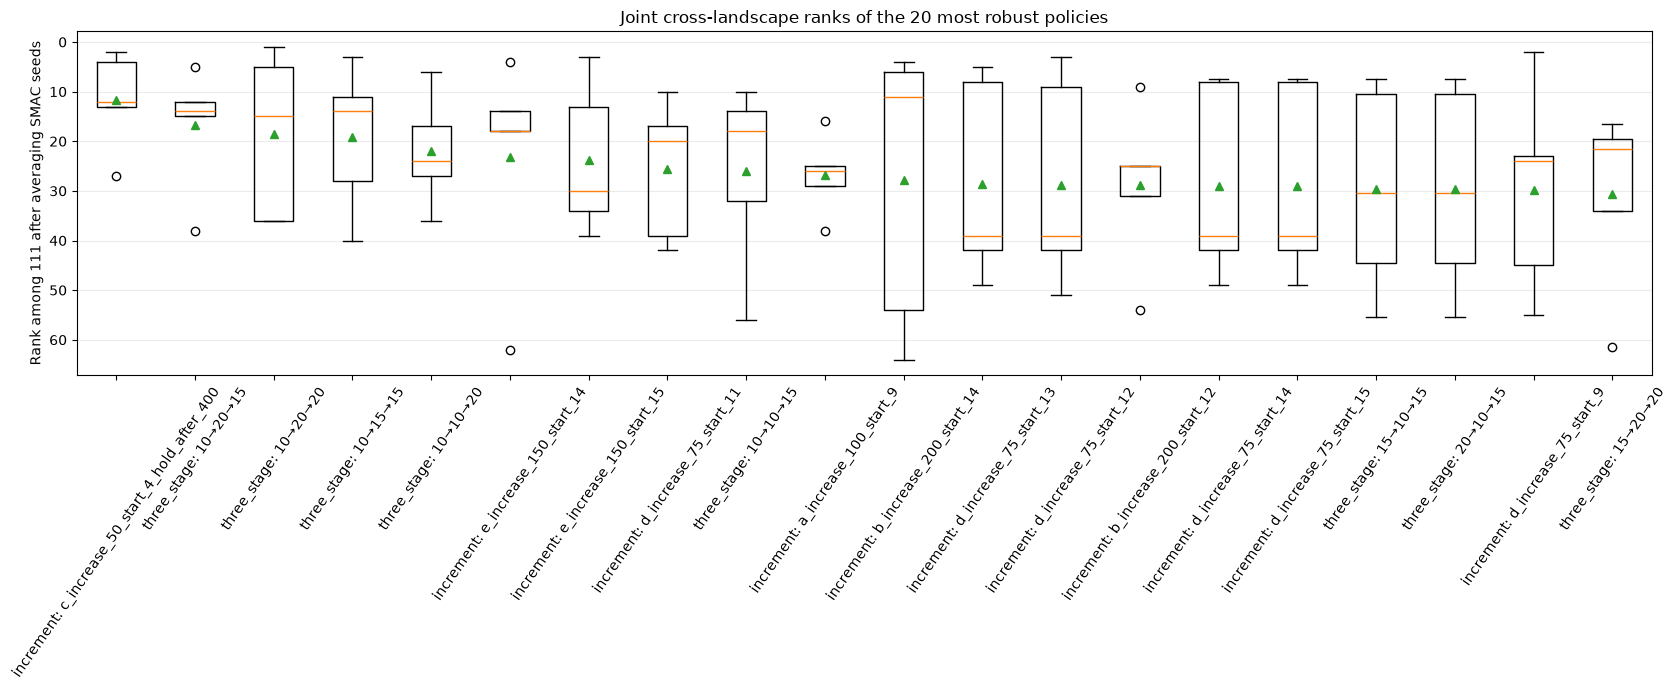

In [14]:
joint_by_benchmark['best_mean'] = joint_by_benchmark.groupby('benchmark_seed').mean_final.transform('min')
joint_by_benchmark['ratio_to_best'] = joint_by_benchmark.mean_final / joint_by_benchmark.best_mean
joint_cross = (joint_by_benchmark.groupby(['candidate_id','source','policy','policy_group','start_depth','final_depth','description'], as_index=False)
    .agg(mean_rank=('final_rank','mean'), median_rank=('final_rank','median'), worst_rank=('final_rank','max'), rank_std=('final_rank','std'),
         geomean_ratio=('ratio_to_best', lambda x: float(np.exp(np.log(x).mean()))), mean_auc_rank=('auc_rank','mean')))
joint_cross = joint_cross.sort_values(['mean_rank','geomean_ratio','worst_rank']).reset_index(drop=True)
joint_cross.index = np.arange(1, len(joint_cross) + 1); joint_cross.index.name = 'joint cross-landscape rank'
joint_top = joint_cross.head(20); display(joint_top)
joint_labels = [f"{row.source}: {row.description}" for row in joint_top.itertuples()]
joint_rank_lists = [joint_by_benchmark.query('candidate_id == @candidate').sort_values('benchmark_seed').final_rank for candidate in joint_top.candidate_id]
fig, ax = plt.subplots(figsize=(17, 7)); ax.boxplot(joint_rank_lists, tick_labels=joint_labels, showmeans=True)
ax.set_ylabel('Rank among 111 after averaging SMAC seeds'); ax.invert_yaxis(); ax.set_title('Joint cross-landscape ranks of the 20 most robust policies')
ax.tick_params(axis='x', rotation=55); ax.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()


## Incrementing versus three-stage policy families

In [15]:
source_summary = joint_cross.groupby('source').agg(policies=('candidate_id','size'), mean_cross_rank=('mean_rank','mean'), median_cross_rank=('mean_rank','median'), best_cross_rank=('mean_rank','min'), mean_geomean_ratio=('geomean_ratio','mean')).sort_values('mean_cross_rank')
display(source_summary)
group_summary = joint_cross.groupby('policy_group').agg(policies=('candidate_id','size'), mean_cross_rank=('mean_rank','mean'), median_cross_rank=('mean_rank','median'), best_cross_rank=('mean_rank','min')).sort_values('mean_cross_rank')
display(group_summary)
top_counts = []
for n in (5, 10, 20):
    selected = joint_by_benchmark.sort_values(['benchmark_seed','mean_final']).groupby('benchmark_seed').head(n)
    counts = selected.groupby('source').size()
    for source in expected_by_source: top_counts.append({'top_n': n, 'source': source, 'occurrences': int(counts.get(source, 0)), 'possible': n * 5})
display(pd.DataFrame(top_counts))
best_each_source = joint_by_benchmark.sort_values(['benchmark_seed','source','mean_final']).groupby(['benchmark_seed','source']).head(1)
display(best_each_source[['benchmark_seed','source','policy','description','mean_final','final_rank']].sort_values(['benchmark_seed','source']))


,policies,mean_cross_rank,median_cross_rank,best_cross_rank,mean_geomean_ratio
source,,,,,
increment,47,43.914894,42.4,11.6,1.614507
three_stage,64,64.875000,64.9,16.8,2.166393


,policies,mean_cross_rank,median_cross_rank,best_cross_rank
policy_group,,,,
increment_d,11,35.636364,29.8,25.6
increment_c,8,40.175000,41.5,11.6
increment_e,11,45.090909,40.4,23.2
increment_a,7,46.714286,43.6,26.8
increment_b,10,52.760000,49.5,27.8
three_stage,64,64.875000,64.9,16.8


,top_n,source,occurrences,possible
0,5,increment,19,25
1,5,three_stage,6,25
2,10,increment,34,50
3,10,three_stage,16,50
4,20,increment,55,100
5,20,three_stage,45,100


,benchmark_seed,source,policy,description,mean_final,final_rank
31,52,increment,d_increase_75_start_5,d_increase_75_start_5,9748.861416,1.0
52,52,three_stage,depth_policy_10_15_15,10→15→15,10173.431154,3.0
116,53,increment,a_increase_100_start_8,a_increase_100_start_8,8484.564387,1.0
211,53,three_stage,depth_policy_5_15_15,5→15→15,9123.677218,3.0
245,54,increment,c_increase_50_start_8_hold_after_400,c_increase_50_start_8_hold_after_400,8741.009125,1.0
323,54,three_stage,depth_policy_5_15_20,5→15→20,10811.401928,3.0
367,55,increment,d_increase_75_start_8,d_increase_75_start_8,5491.475151,2.0
390,55,three_stage,depth_policy_10_20_20,10→20→20,5359.927810,1.0
461,56,increment,c_increase_50_start_10_hold_after_400,c_increase_50_start_10_hold_after_400,4734.458000,1.0
508,56,three_stage,depth_policy_15_10_15,15→10→15,6514.756746,10.5


## Joint 25-point paired-rank variability

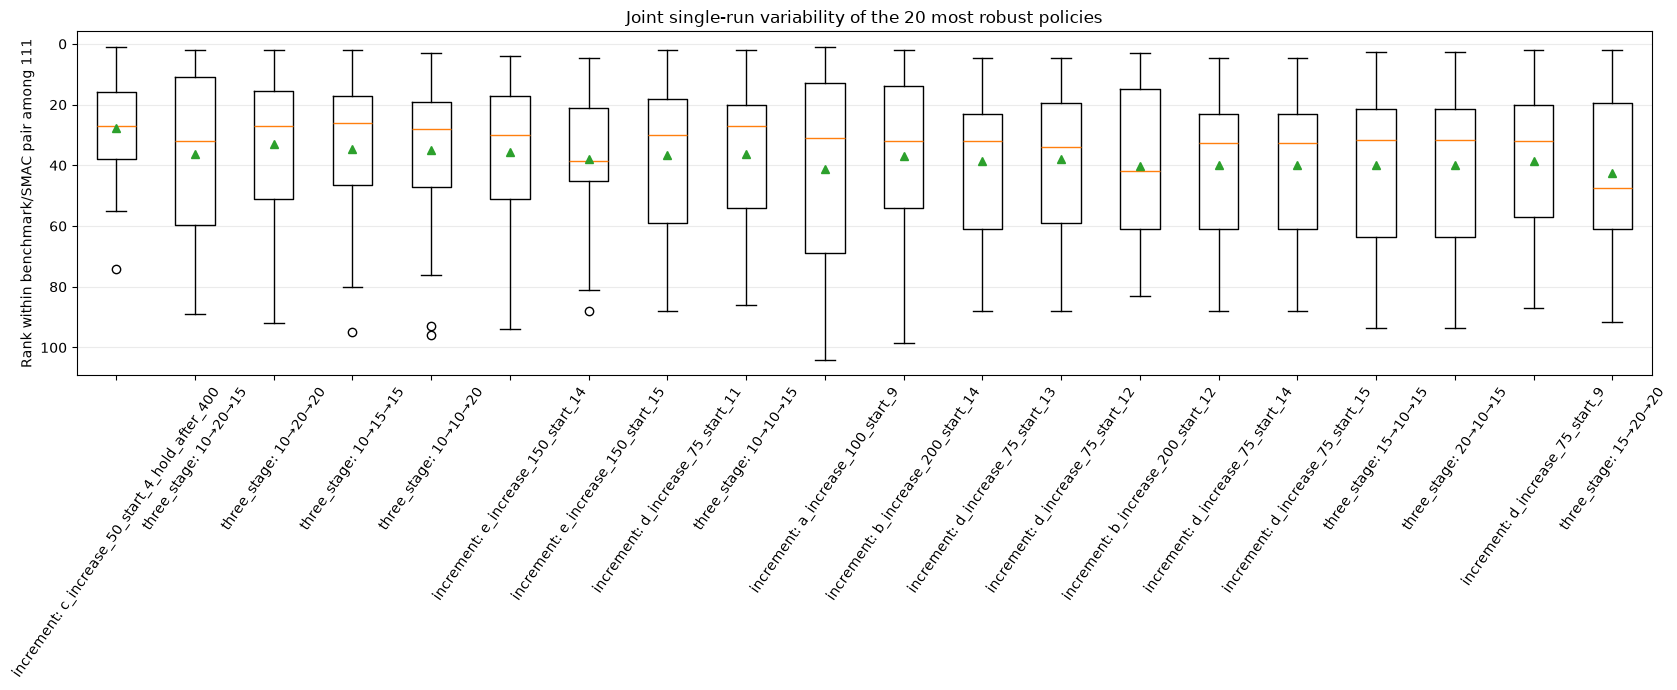

In [16]:
joint_paired = joint.copy()
joint_paired['paired_rank'] = joint_paired.groupby(['benchmark_seed','smac_seed']).final_regret.rank(method='average')
joint_paired_lists = [joint_paired.query('candidate_id == @candidate').sort_values(['benchmark_seed','smac_seed']).paired_rank for candidate in joint_top.candidate_id]
if not all(len(values) == 25 for values in joint_paired_lists): raise ValueError('Expected 25 paired ranks per policy.')
fig, ax = plt.subplots(figsize=(17, 7)); ax.boxplot(joint_paired_lists, tick_labels=joint_labels, showmeans=True)
ax.set_ylabel('Rank within benchmark/SMAC pair among 111'); ax.invert_yaxis(); ax.set_title('Joint single-run variability of the 20 most robust policies')
ax.tick_params(axis='x', rotation=55); ax.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()


## Joint rank correlations between landscapes

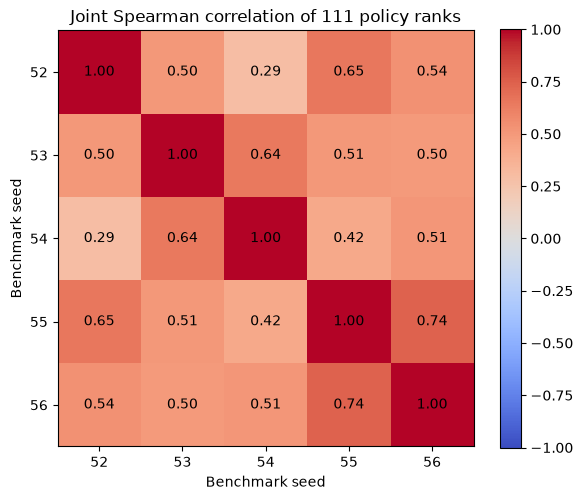

benchmark_seed,52,53,54,55,56
benchmark_seed,,,,,
52,1.000000,0.501465,0.290189,0.650514,0.537534
53,0.501465,1.000000,0.643077,0.505095,0.499228
54,0.290189,0.643077,1.000000,0.416993,0.508539
55,0.650514,0.505095,0.416993,1.000000,0.736950
56,0.537534,0.499228,0.508539,0.736950,1.000000


In [17]:
joint_rank_matrix = joint_by_benchmark.pivot(index='candidate_id', columns='benchmark_seed', values='final_rank').reindex(columns=BENCHMARK_SEEDS)
joint_correlation = joint_rank_matrix.corr(method='spearman')
fig, ax = plt.subplots(figsize=(6, 5)); image = ax.imshow(joint_correlation, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(5), BENCHMARK_SEEDS); ax.set_yticks(range(5), BENCHMARK_SEEDS); ax.set_xlabel('Benchmark seed'); ax.set_ylabel('Benchmark seed'); ax.set_title('Joint Spearman correlation of 111 policy ranks')
for i in range(5):
    for j in range(5): ax.text(j, i, f'{joint_correlation.iloc[i,j]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax); plt.tight_layout(); plt.show(); display(joint_correlation)


## Joint leave-one-benchmark-seed-out selection

In [18]:
joint_lobo = []
for held_out in BENCHMARK_SEEDS:
    dynamic_choice = joint_by_benchmark.query('benchmark_seed != @held_out').groupby('candidate_id').final_rank.mean().idxmin()
    fixed_choice = fixed_by_benchmark.query('benchmark_seed != @held_out').groupby('policy').fixed_rank.mean().idxmin()
    dynamic_test = joint_by_benchmark.query('benchmark_seed == @held_out and candidate_id == @dynamic_choice').iloc[0]
    fixed_test = fixed_by_benchmark.query('benchmark_seed == @held_out and policy == @fixed_choice').iloc[0]
    joint_lobo.append({'held_out_seed': held_out, 'selected_source': dynamic_test.source, 'dynamic_policy': dynamic_test.policy,
                       'dynamic_description': dynamic_test.description, 'held_out_rank_of_111': dynamic_test.final_rank,
                       'dynamic_final': dynamic_test.mean_final, 'fixed_policy': fixed_choice, 'fixed_final': fixed_test.mean_final,
                       'dynamic_improvement_percent': 100 * (fixed_test.mean_final - dynamic_test.mean_final) / fixed_test.mean_final})
joint_lobo = pd.DataFrame(joint_lobo); display(joint_lobo)
print(f"Dynamic wins {(joint_lobo.dynamic_improvement_percent > 0).sum()}/5 held-out landscapes; mean change {joint_lobo.dynamic_improvement_percent.mean():.2f}%")


,held_out_seed,selected_source,dynamic_policy,dynamic_description,held_out_rank_of_111,dynamic_final,fixed_policy,fixed_final,dynamic_improvement_percent
0,52,increment,e_increase_150_start_14,e_increase_150_start_14,62.0,15078.417202,fixed_depth_20,13626.058972,-10.658682
1,53,three_stage,depth_policy_10_20_15,10→20→15,38.0,14343.648594,fixed_depth_20,16080.433192,10.800608
2,54,increment,c_increase_50_start_4_hold_after_400,c_increase_50_start_4_hold_after_400,13.0,11524.622538,fixed_depth_15,13616.517973,15.362925
3,55,increment,c_increase_50_start_4_hold_after_400,c_increase_50_start_4_hold_after_400,12.0,6584.403617,fixed_depth_15,7662.505106,14.069831
4,56,increment,c_increase_50_start_4_hold_after_400,c_increase_50_start_4_hold_after_400,27.0,7232.694328,fixed_depth_15,6970.866727,-3.756027


Dynamic wins 3/5 held-out landscapes; mean change 5.16%


## Joint-analysis interpretation checklist

- The two policy sources have different numbers of candidates (47 versus 64); compare rank distributions and best transferable members, not only raw top-policy counts.
- A policy entering many per-landscape top lists is exploratory evidence; prioritize joint leave-one-landscape-out performance.
- Fixed trajectories are required to be exactly reproducible across both experiment folders before they are used as a shared baseline.
- The combined analysis expands the candidate set after seeing earlier results, so final claims still require confirmation on new benchmark seeds.